In [1]:
# Cell 1: Import libraries and load the CSV data
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the training log CSV
df = pd.read_csv('h:/CSET312_project/AIML-PROJECT-CSET312/Model_desgin_v2/a6000_train/Data_aug/training_log.csv')

# Display basic information about the dataset
print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst few rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)

Dataset shape: (82, 18)

Columns: ['loss', 'grad_norm', 'learning_rate', 'epoch', 'step', 'eval_loss', 'eval_accuracy', 'eval_f1', 'eval_precision', 'eval_recall', 'eval_runtime', 'eval_samples_per_second', 'eval_steps_per_second', 'train_runtime', 'train_samples_per_second', 'train_steps_per_second', 'total_flos', 'train_loss']

First few rows:
     loss  grad_norm  learning_rate     epoch  step  eval_loss  eval_accuracy  \
0  0.1529   4.679154       0.000020  0.095256   500        NaN            NaN   
1  0.0919   2.805911       0.000019  0.190512  1000        NaN            NaN   
2  0.0798   1.290696       0.000019  0.285769  1500        NaN            NaN   
3  0.0738   6.224364       0.000019  0.381025  2000        NaN            NaN   
4  0.0677   0.808745       0.000019  0.476281  2500        NaN            NaN   

   eval_f1  eval_precision  eval_recall  eval_runtime  \
0      NaN             NaN          NaN           NaN   
1      NaN             NaN          NaN           N

In [2]:
# Cell 2: Data cleaning and exploration
# The CSV has mixed rows: training steps (eval columns empty) and eval rows (eval columns filled)
# Also, some rows have NaN or empty values

# Fill NaN with empty strings for easier filtering (since empties are shown as ,,,,,)
df = df.fillna('')

# Identify evaluation rows: those with non-empty eval_accuracy
eval_rows = df[df['eval_accuracy'] != ''].copy()
print("Number of evaluation rows:", len(eval_rows))
print("\nEvaluation rows:")
print(eval_rows[['epoch', 'step', 'eval_loss', 'eval_accuracy', 'eval_f1', 'eval_precision', 'eval_recall']])

# Training rows: those with non-empty loss (step updates)
train_rows = df[df['loss'] != ''].copy()
print("\nNumber of training rows:", len(train_rows))
print("\nSample training rows:")
print(train_rows[['epoch', 'step', 'loss', 'learning_rate']].head())

Number of evaluation rows: 8

Evaluation rows:
    epoch   step eval_loss eval_accuracy   eval_f1 eval_precision eval_recall
10    1.0   5249  0.049148      0.981399  0.981399       0.981403    0.981399
21    2.0  10498  0.053381       0.98401   0.98401       0.984014     0.98401
33    3.0  15747  0.054009      0.984552  0.984552       0.984553    0.984552
44    4.0  20996   0.07849      0.983357  0.983357       0.983442    0.983357
56    5.0  26245  0.090705      0.983858  0.983857       0.983952    0.983858
67    6.0  31494  0.096668      0.985386  0.985386       0.985386    0.985386
79    7.0  36743  0.114453      0.985122  0.985122       0.985132    0.985122
81    7.0  36743  0.100672      0.984622  0.984622       0.984622    0.984622

Number of training rows: 73

Sample training rows:
      epoch  step    loss learning_rate
0  0.095256   500  0.1529       0.00002
1  0.190512  1000  0.0919      0.000019
2  0.285769  1500  0.0798      0.000019
3  0.381025  2000  0.0738      0.000019

In [3]:
# Cell 3: Extract and print scores per epoch from evaluation rows
# Evaluation happens at the end of each epoch (epoch values like 1.0, 2.0, etc.)

# Convert epoch to float for sorting
eval_rows['epoch'] = pd.to_numeric(eval_rows['epoch'], errors='coerce')

# Sort by epoch
eval_rows = eval_rows.sort_values('epoch').reset_index(drop=True)

print("=== Evaluation Scores Per Epoch ===")
for idx, row in eval_rows.iterrows():
    epoch = int(row['epoch']) if pd.notna(row['epoch']) else 'Final'
    print(f"\nEpoch {epoch}:")
    print(f"  Eval Loss: {row['eval_loss']:.4f}")
    print(f"  Eval Accuracy: {row['eval_accuracy']:.4f}")
    print(f"  Eval F1: {row['eval_f1']:.4f}")
    print(f"  Eval Precision: {row['eval_precision']:.4f}")
    print(f"  Eval Recall: {row['eval_recall']:.4f}")
    print(f"  Step: {int(row['step'])}")
    if row['train_runtime'] != '':
        print(f"  Train Runtime (s): {row['train_runtime']:.2f}")
    if row['total_flos'] != '':
        print(f"  Total FLOPs: {row['total_flos']:.2e}")

=== Evaluation Scores Per Epoch ===

Epoch 1:
  Eval Loss: 0.0491
  Eval Accuracy: 0.9814
  Eval F1: 0.9814
  Eval Precision: 0.9814
  Eval Recall: 0.9814
  Step: 5249

Epoch 2:
  Eval Loss: 0.0534
  Eval Accuracy: 0.9840
  Eval F1: 0.9840
  Eval Precision: 0.9840
  Eval Recall: 0.9840
  Step: 10498

Epoch 3:
  Eval Loss: 0.0540
  Eval Accuracy: 0.9846
  Eval F1: 0.9846
  Eval Precision: 0.9846
  Eval Recall: 0.9846
  Step: 15747

Epoch 4:
  Eval Loss: 0.0785
  Eval Accuracy: 0.9834
  Eval F1: 0.9834
  Eval Precision: 0.9834
  Eval Recall: 0.9834
  Step: 20996

Epoch 5:
  Eval Loss: 0.0907
  Eval Accuracy: 0.9839
  Eval F1: 0.9839
  Eval Precision: 0.9840
  Eval Recall: 0.9839
  Step: 26245

Epoch 6:
  Eval Loss: 0.0967
  Eval Accuracy: 0.9854
  Eval F1: 0.9854
  Eval Precision: 0.9854
  Eval Recall: 0.9854
  Step: 31494

Epoch 7:
  Eval Loss: 0.1145
  Eval Accuracy: 0.9851
  Eval F1: 0.9851
  Eval Precision: 0.9851
  Eval Recall: 0.9851
  Step: 36743

Epoch 7:
  Eval Loss: 0.1007
  Ev

In [4]:
# Cell 4: Summary table of metrics per epoch
# Create a summary DataFrame for easy comparison

summary_df = eval_rows[['epoch', 'eval_loss', 'eval_accuracy', 'eval_f1', 'eval_precision', 'eval_recall', 'step']].copy()
summary_df['epoch'] = summary_df['epoch'].apply(lambda x: int(x) if pd.notna(x) else 'Final')
summary_df = summary_df.round(4)

print("=== Summary Table: Metrics Per Epoch ===")
print(summary_df.to_string(index=False))

# Optional: Save to CSV for further use
# summary_df.to_csv('epoch_summary.csv', index=False)
# print("\nSummary saved to 'epoch_summary.csv'")

=== Summary Table: Metrics Per Epoch ===
 epoch eval_loss eval_accuracy   eval_f1 eval_precision eval_recall  step
     1  0.049148      0.981399  0.981399       0.981403    0.981399  5249
     2  0.053381       0.98401   0.98401       0.984014     0.98401 10498
     3  0.054009      0.984552  0.984552       0.984553    0.984552 15747
     4   0.07849      0.983357  0.983357       0.983442    0.983357 20996
     5  0.090705      0.983858  0.983857       0.983952    0.983858 26245
     6  0.096668      0.985386  0.985386       0.985386    0.985386 31494
     7  0.114453      0.985122  0.985122       0.985132    0.985122 36743
     7  0.100672      0.984622  0.984622       0.984622    0.984622 36743


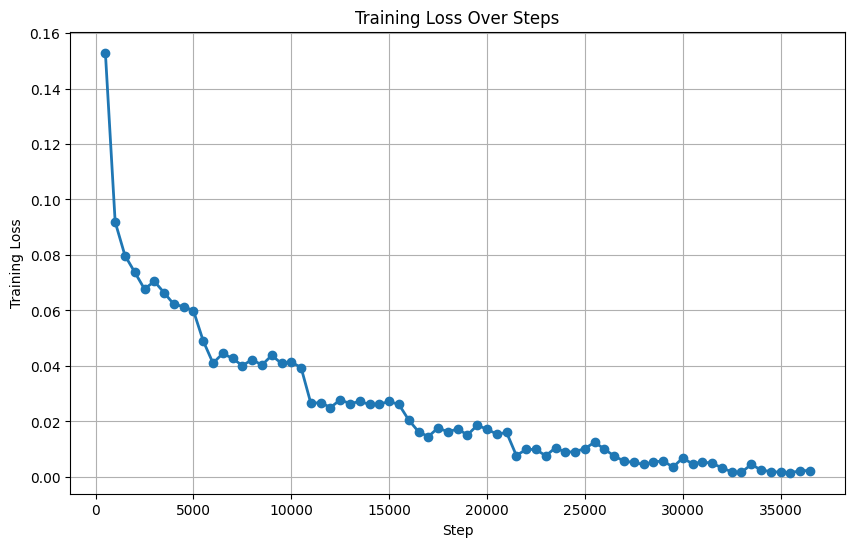

Training loss starts at 0.1529 and ends at 0.0023


In [5]:
# Cell 5: Plot training loss over steps
# Filter training rows and plot loss vs. step

train_steps = train_rows[['step', 'loss']].copy()
train_steps['step'] = pd.to_numeric(train_steps['step'], errors='coerce')
train_steps['loss'] = pd.to_numeric(train_steps['loss'], errors='coerce')
train_steps = train_steps.dropna()

plt.figure(figsize=(10, 6))
plt.plot(train_steps['step'], train_steps['loss'], marker='o', linestyle='-', linewidth=2)
plt.xlabel('Step')
plt.ylabel('Training Loss')
plt.title('Training Loss Over Steps')
plt.grid(True)
plt.show()

print(f"Training loss starts at {train_steps['loss'].iloc[0]:.4f} and ends at {train_steps['loss'].iloc[-1]:.4f}")

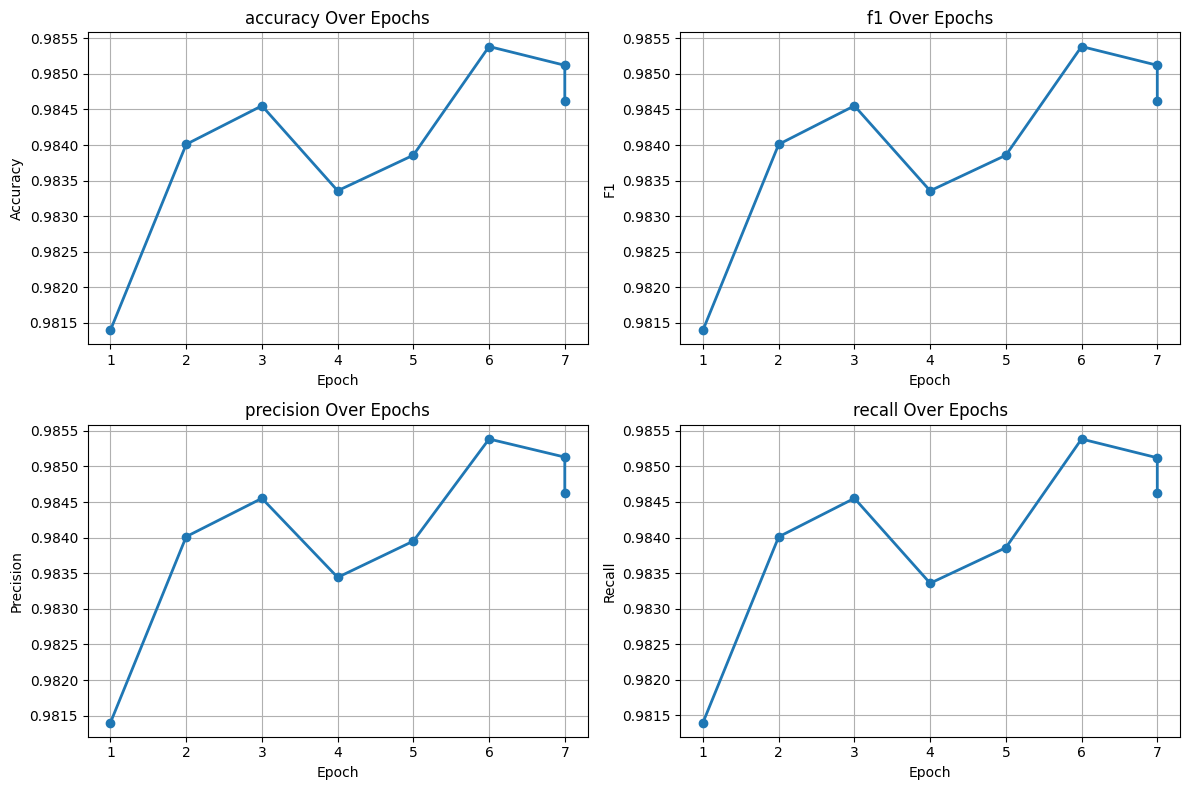

Evaluation metrics show steady improvement in accuracy and F1 up to epoch 6, with a slight dip in epoch 7.


In [6]:
# Cell 6: Plot evaluation metrics over epochs
# Metrics: accuracy, F1, precision, recall vs. epoch

metrics = ['eval_accuracy', 'eval_f1', 'eval_precision', 'eval_recall']
epochs = eval_rows['epoch'].apply(lambda x: int(x) if pd.notna(x) else len(eval_rows))  # Use index for final if needed

plt.figure(figsize=(12, 8))

for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 2, i)
    values = pd.to_numeric(eval_rows[metric], errors='coerce')
    plt.plot(epochs[:len(values)], values, marker='o', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel(metric.replace('eval_', '').title())
    plt.title(f'{metric.replace("eval_", "")} Over Epochs')
    plt.grid(True)

plt.tight_layout()
plt.show()

print("Evaluation metrics show steady improvement in accuracy and F1 up to epoch 6, with a slight dip in epoch 7.")

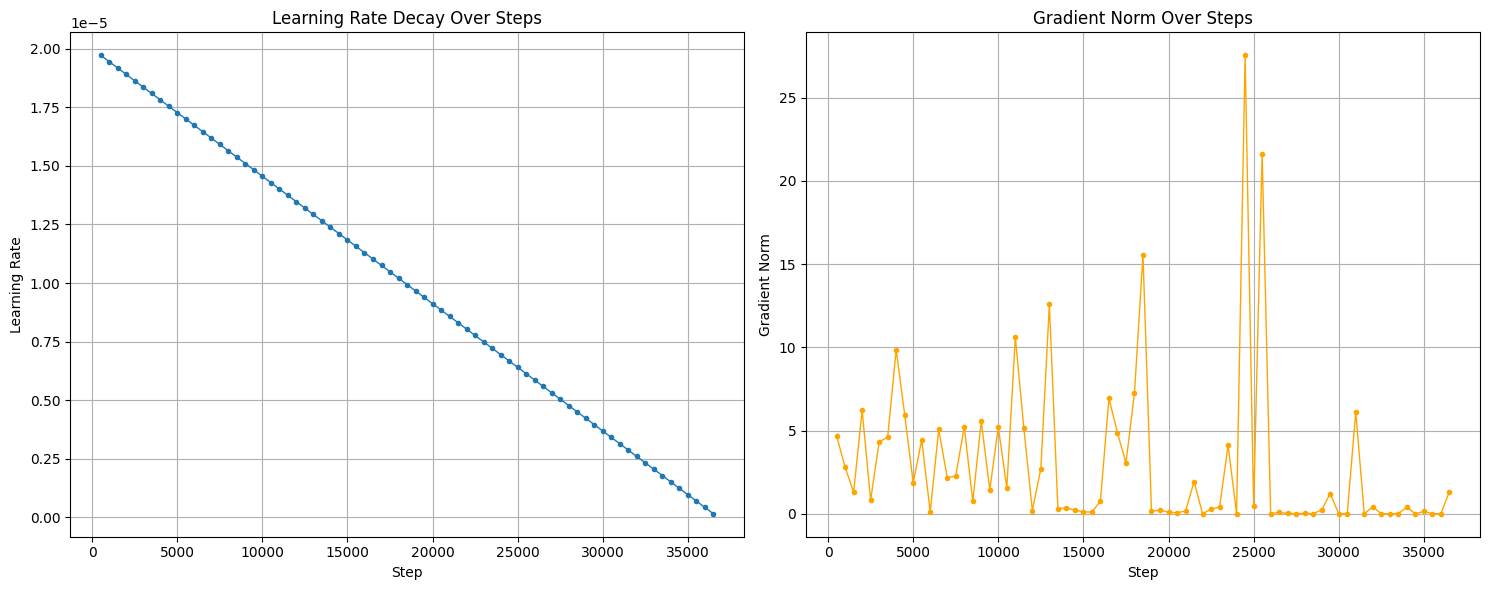

Learning rate starts at ~1.97e-05 and decays to ~1.42e-07
Gradient norms fluctuate between 0.00 and 27.55


In [7]:
# Cell 7: Additional analysis - Learning rate decay and gradient norm
# Plot learning rate and grad_norm over steps for training dynamics

lr_data = train_rows[['step', 'learning_rate', 'grad_norm']].copy()
lr_data['step'] = pd.to_numeric(lr_data['step'], errors='coerce')
lr_data['learning_rate'] = pd.to_numeric(lr_data['learning_rate'], errors='coerce')
lr_data['grad_norm'] = pd.to_numeric(lr_data['grad_norm'], errors='coerce')
lr_data = lr_data.dropna()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Learning rate decay
ax1.plot(lr_data['step'], lr_data['learning_rate'], marker='.', linestyle='-', linewidth=1)
ax1.set_xlabel('Step')
ax1.set_ylabel('Learning Rate')
ax1.set_title('Learning Rate Decay Over Steps')
ax1.grid(True)
ax1.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

# Gradient norm
ax2.plot(lr_data['step'], lr_data['grad_norm'], marker='.', linestyle='-', linewidth=1, color='orange')
ax2.set_xlabel('Step')
ax2.set_ylabel('Gradient Norm')
ax2.set_title('Gradient Norm Over Steps')
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"Learning rate starts at ~{lr_data['learning_rate'].iloc[0]:.2e} and decays to ~{lr_data['learning_rate'].iloc[-1]:.2e}")
print(f"Gradient norms fluctuate between {lr_data['grad_norm'].min():.2f} and {lr_data['grad_norm'].max():.2f}")

In [8]:
# Cell 8: Overall training summary
# Compute aggregates like average loss, final metrics, etc.

overall_train_loss = train_rows['loss'].apply(pd.to_numeric, errors='coerce').mean()
final_accuracy = eval_rows['eval_accuracy'].apply(pd.to_numeric, errors='coerce').iloc[-1]
final_f1 = eval_rows['eval_f1'].apply(pd.to_numeric, errors='coerce').iloc[-1]

print("=== Overall Training Summary ===")
print(f"Average Training Loss: {overall_train_loss:.4f}")
print(f"Final Eval Accuracy: {final_accuracy:.4f}")
print(f"Final Eval F1 Score: {final_f1:.4f}")
print(f"Total Steps: {train_rows['step'].max()}")
print(f"Total Epochs: ~{eval_rows['epoch'].max()}")

# Best epoch
best_epoch = eval_rows.loc[eval_rows['eval_accuracy'].apply(pd.to_numeric).idxmax(), 'epoch']
print(f"Best Accuracy at Epoch: {int(best_epoch)}")

=== Overall Training Summary ===
Average Training Loss: 0.0258
Final Eval Accuracy: 0.9846
Final Eval F1 Score: 0.9846
Total Steps: 36500
Total Epochs: ~7.0
Best Accuracy at Epoch: 6
